[Notebook downloaded from KAGGLE for evaluation](https://www.kaggle.com/code/baskaranthirumoorthy/predicting-heart-disease)

        # **Heart Disease Prediction Using Machine Learning**

    Heart disease is one of the leading causes of death worldwide. 
    Early prediction can help doctors and patients take preventive actions.
    In this project, I used the Framingham Heart Study dataset to build machine learning models 
    that predict the risk of developing coronary heart disease within 10 years.
    The dataset includes health indicators such as age, cholesterol, blood pressure,
    BMI, glucose level, smoking habits, and diabetes.

    **Models Used**

    1. Logistic Regression
    2. Random Forest Classifier

    **Methodology**

    1. Loaded the dataset using pandas
    2. Handled missing values using mean/median/mode
    3. Selected important health-related features
    4. Split the dataset into 80% training and 20% testing
    5. Applied StandardScaler for feature scaling
    6. Trained the models
    7. Evaluated performance using accuracy, confusion matrix, classification report, and ROC-AUC score


    **Conclusion**

    The models were able to predict heart disease risk using patient health data.
    This project demonstrates how machine learning can assist in early detection and preventive healthcare.

**Import Required Libraries**

In [38]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

    Necessary libraries imported

In [39]:
df=pd.read_csv('framingham.csv')

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4238 non-null   int64  
 1   age              4238 non-null   int64  
 2   education        4133 non-null   float64
 3   currentSmoker    4238 non-null   int64  
 4   cigsPerDay       4209 non-null   float64
 5   BPMeds           4185 non-null   float64
 6   prevalentStroke  4238 non-null   int64  
 7   prevalentHyp     4238 non-null   int64  
 8   diabetes         4238 non-null   int64  
 9   totChol          4188 non-null   float64
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4219 non-null   float64
 13  heartRate        4237 non-null   float64
 14  glucose          3850 non-null   float64
 15  TenYearCHD       4238 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 529.9 KB


In [41]:
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


**Missing Value Analysis**

In [42]:
df.isnull()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4233,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4234,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4235,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
4236,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False


In [43]:
df.isnull().sum()

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

**Handling Missing Values**

In [44]:
Null_value = df[df['education'].isnull()|df['cigsPerDay'].isnull()|df['BPMeds'].isnull()|df['totChol'].isnull()|df['BMI'].isnull()|df['heartRate'].isnull()|df['glucose'].isnull()]
display(Null_value)

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
14,0,39,2.0,1,9.0,0.0,0,0,0,226.0,114.0,64.0,22.35,85.0,NaN,0
21,0,43,1.0,0,0.0,0.0,0,0,0,185.0,123.5,77.5,29.89,70.0,NaN,0
26,0,60,1.0,0,0.0,0.0,0,0,0,260.0,110.0,72.5,26.59,65.0,NaN,0
33,1,61,NaN,1,5.0,0.0,0,0,0,175.0,134.0,82.5,18.59,72.0,75.0,1
36,1,56,NaN,0,0.0,0.0,0,0,0,257.0,153.5,102.0,28.09,72.0,75.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4208,0,51,1.0,1,9.0,0.0,0,0,0,340.0,152.0,76.0,25.74,70.0,NaN,0
4229,0,51,3.0,1,20.0,0.0,0,1,0,251.0,140.0,80.0,25.60,75.0,NaN,0
4230,0,56,1.0,1,3.0,0.0,0,1,0,268.0,170.0,102.0,22.89,57.0,NaN,0
4235,0,48,2.0,1,20.0,NaN,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0


In [45]:
df['cigsPerDay'] = df['cigsPerDay'].fillna(df['cigsPerDay'].median())
df['BPMeds'] = df['BPMeds'].fillna(df['BPMeds'].mode()[0])
df['totChol'] = df['totChol'].fillna(df['totChol'].mean())
df['BMI'] = df['BMI'].fillna(df['BMI'].mean())
df['heartRate'] = df['heartRate'].fillna(df['heartRate'].mean())
df['glucose'] = df['glucose'].fillna(df['glucose'].median())

In [46]:
df.isnull().sum()

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay           0
BPMeds               0
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol              0
sysBP                0
diaBP                0
BMI                  0
heartRate            0
glucose              0
TenYearCHD           0
dtype: int64

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4238 non-null   int64  
 1   age              4238 non-null   int64  
 2   education        4133 non-null   float64
 3   currentSmoker    4238 non-null   int64  
 4   cigsPerDay       4238 non-null   float64
 5   BPMeds           4238 non-null   float64
 6   prevalentStroke  4238 non-null   int64  
 7   prevalentHyp     4238 non-null   int64  
 8   diabetes         4238 non-null   int64  
 9   totChol          4238 non-null   float64
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4238 non-null   float64
 13  heartRate        4238 non-null   float64
 14  glucose          4238 non-null   float64
 15  TenYearCHD       4238 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 529.9 KB


    Drawing plots with seaborn 

**Exploratory Data Analysis (EDA)**

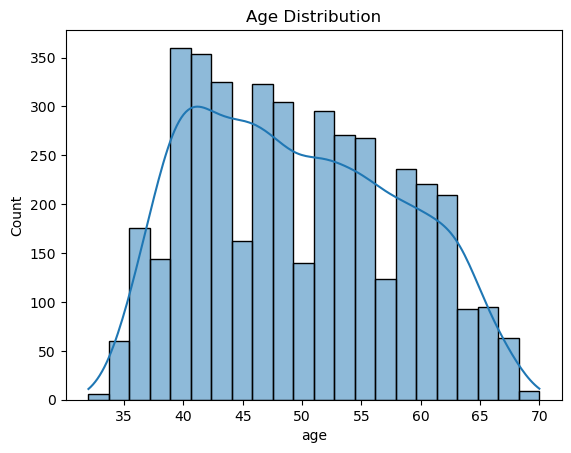

In [48]:
sns.histplot(df['age'], kde=True)
plt.title("Age Distribution")
plt.show()

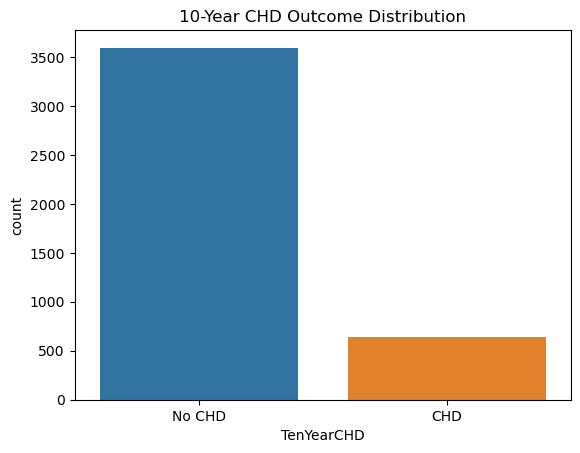

In [49]:
sns.countplot(x='TenYearCHD', data=df)
plt.title("10-Year CHD Outcome Distribution")
plt.xticks([0,1], ['No CHD','CHD'])
plt.show()

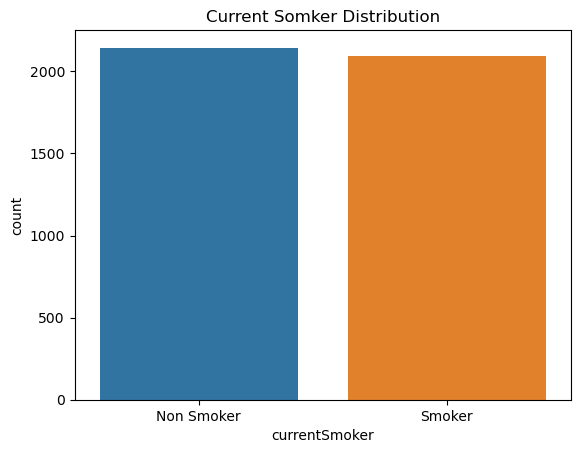

In [50]:
sns.countplot(x='currentSmoker', data=df)
plt.title('Current Somker Distribution')
plt.xticks([0,1], ['Non Smoker','Smoker'])
plt.show()

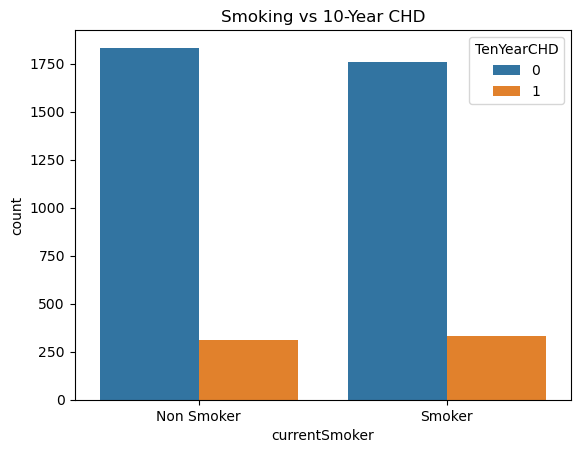

In [51]:
sns.countplot(x='currentSmoker',hue='TenYearCHD', data=df)
plt.title('Smoking vs 10-Year CHD')
plt.xticks([0,1], ['Non Smoker','Smoker'])
plt.show()

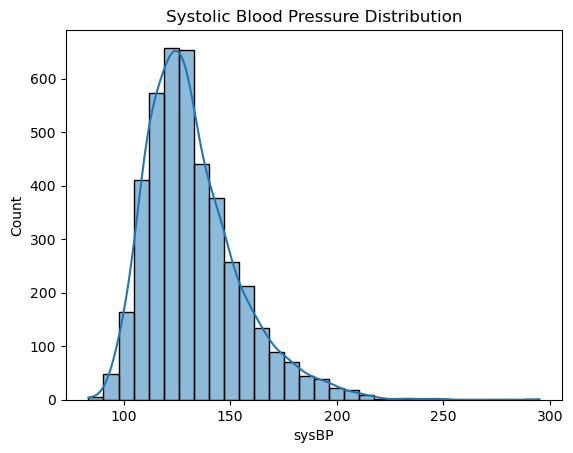

In [52]:
sns.histplot(df['sysBP'],kde=True,bins=30)
plt.title('Systolic Blood Pressure Distribution')
plt.show()

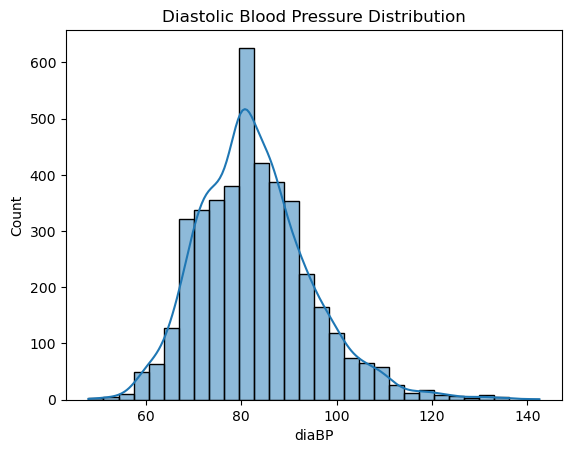

In [53]:
sns.histplot(df['diaBP'],kde=True,bins=30)
plt.title('Diastolic Blood Pressure Distribution')
plt.show()

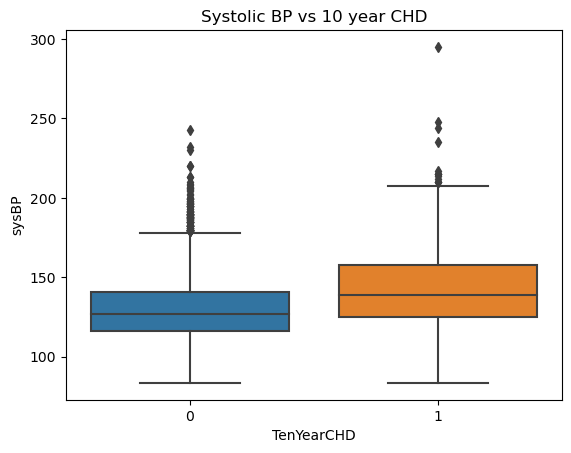

In [54]:
sns.boxplot(x='TenYearCHD',data=df,y='sysBP')
plt.title('Systolic BP vs 10 year CHD')
plt.show()

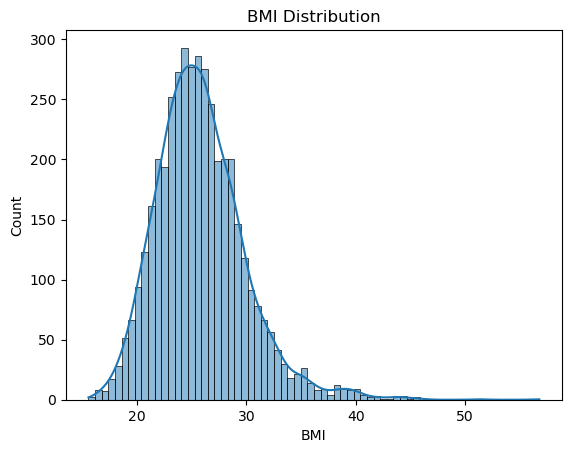

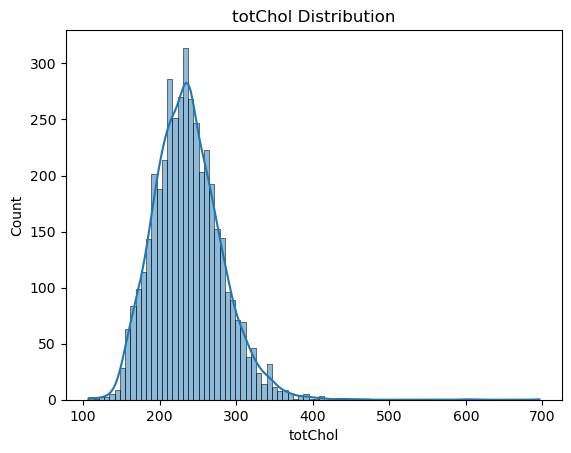

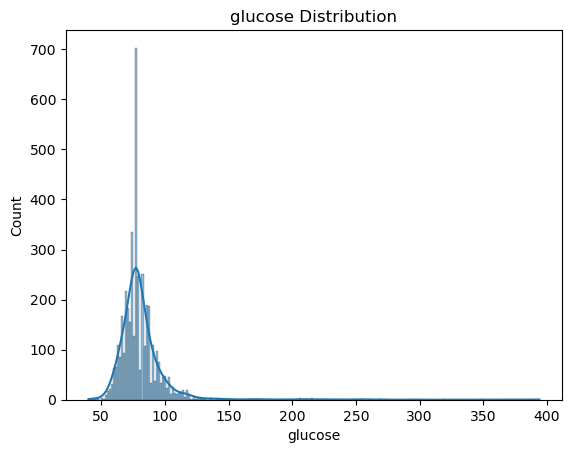

In [55]:
numeric_cols = ['BMI','totChol','glucose']

for col in numeric_cols:
    sns.histplot(df[col], kde=True)
    plt.title(f"{col} Distribution")
    plt.show()

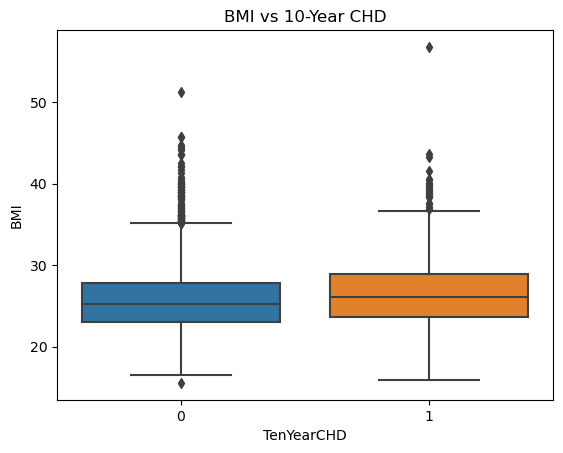

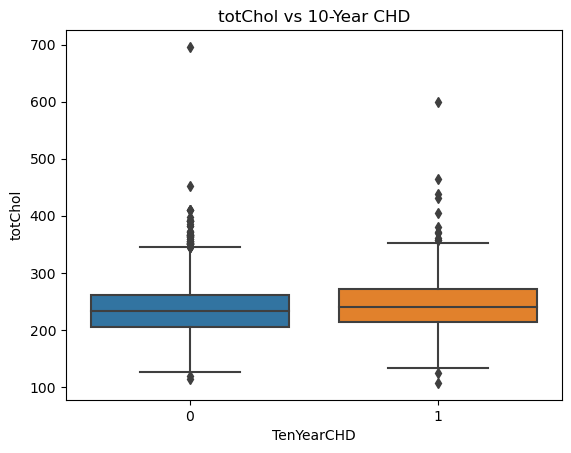

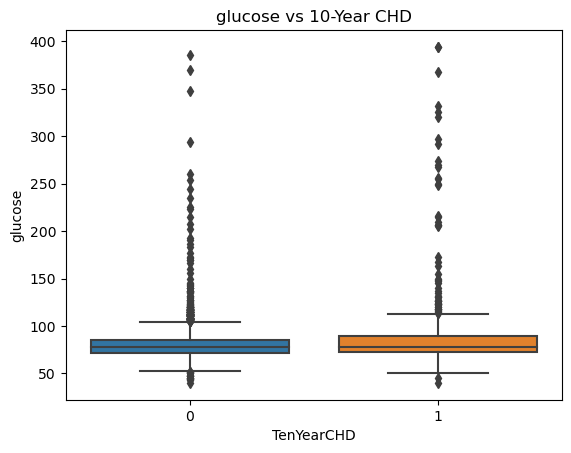

In [56]:
# Boxplots vs CHD
for col in numeric_cols:
    sns.boxplot(x='TenYearCHD', y=col, data=df)
    plt.title(f"{col} vs 10-Year CHD")
    plt.show()

**Feature Correlation Analysis**

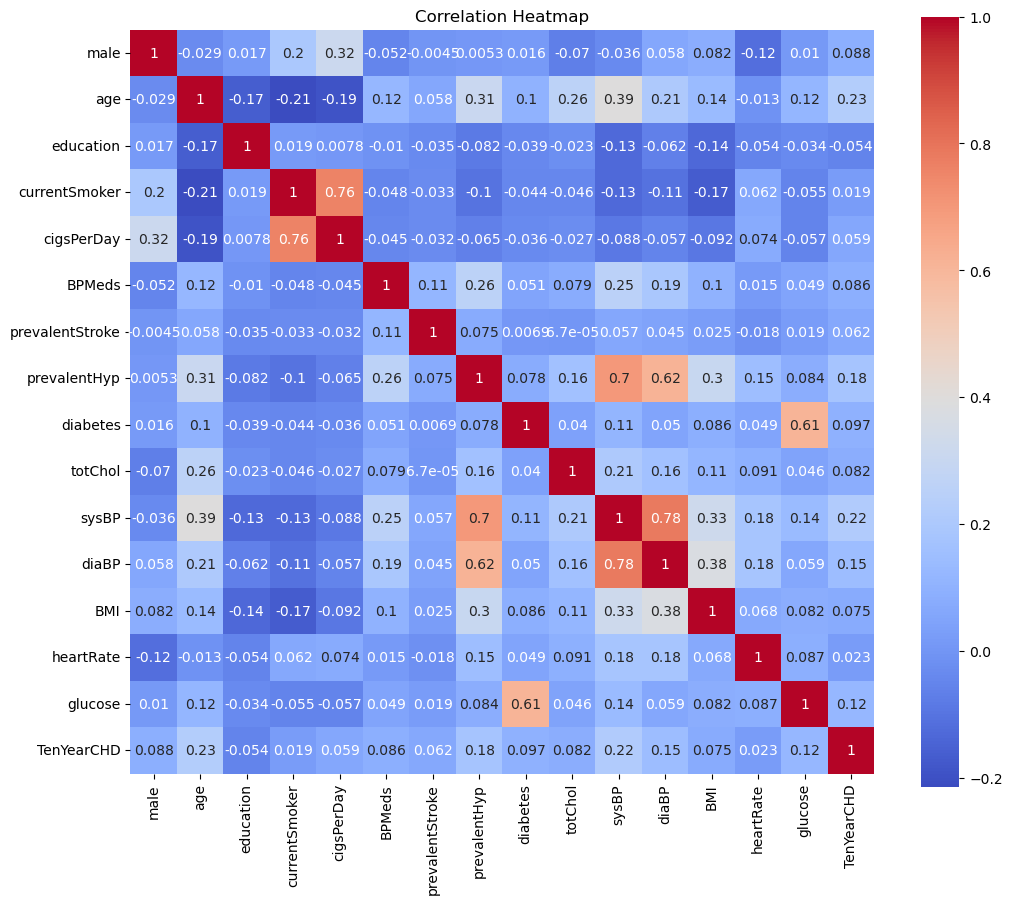

In [57]:
plt.figure(figsize=(12,10))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', square=True)
plt.title("Correlation Heatmap")
plt.show()

    In this feature selection part features and target column are selected differently from what we learn (with drop() function)

**Feature Selection**

In [58]:
x = df[['male','age','currentSmoker','cigsPerDay','BPMeds',
             'prevalentStroke','prevalentHyp','diabetes','totChol',
             'sysBP','diaBP','BMI','heartRate','glucose']]
y = df['TenYearCHD']

**Feature Scaling and Test Spliting**

In [59]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.2, random_state= 12)

sc = StandardScaler()

    StandartScaler is chosen

In [60]:
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

    x_test value scaled with transform() function not fit_transform()

**Logistic Regression Model**

In [61]:
from sklearn.linear_model import LogisticRegression
LR_model = LogisticRegression()
LR_model.fit(x_train, y_train)

LogisticRegression()

**Model Prediction**

In [62]:
LR_y_pred_test = LR_model.predict(x_test)
print(LR_y_pred_test)

[0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 

**Random Forest Model**

In [63]:
from sklearn.ensemble import RandomForestClassifier
RF_model = RandomForestClassifier(n_estimators=200,random_state=42)
RF_model.fit(x_train,y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

**Model Prediction**

In [64]:
RF_y_pred_test = RF_model.predict(x_test)
RF_y_pred_test

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

**Model Evaluation**

In [65]:
LR_model.score(x_test, y_test)

0.8419811320754716

In [66]:
RF_model.score(x_test,y_test)

0.8349056603773585

In [67]:
from sklearn.metrics import classification_report,accuracy_score
print("\n===== Logistic Regression =====")
print("Accuracy:", accuracy_score(y_test, LR_y_pred_test))
print(classification_report(y_test, LR_y_pred_test))


print("\n===== Random Forest =====")
print("Accuracy:", accuracy_score(y_test, RF_y_pred_test))
print(classification_report(y_test, RF_y_pred_test))


===== Logistic Regression =====
Accuracy: 0.8419811320754716
              precision    recall  f1-score   support

           0       0.84      0.99      0.91       708
           1       0.71      0.07      0.13       140

    accuracy                           0.84       848
   macro avg       0.78      0.53      0.52       848
weighted avg       0.82      0.84      0.78       848


===== Random Forest =====
Accuracy: 0.8349056603773585
              precision    recall  f1-score   support

           0       0.84      0.99      0.91       708
           1       0.50      0.05      0.09       140

    accuracy                           0.83       848
   macro avg       0.67      0.52      0.50       848
weighted avg       0.78      0.83      0.77       848



**Confusion Matrix**

In [68]:
from sklearn.metrics import confusion_matrix
print("\n===== Logistic Regression =====")
LR_cm = confusion_matrix(y_test, LR_y_pred_test)
LR_cm


===== Logistic Regression =====


array([[704,   4],
       [130,  10]], dtype=int64)

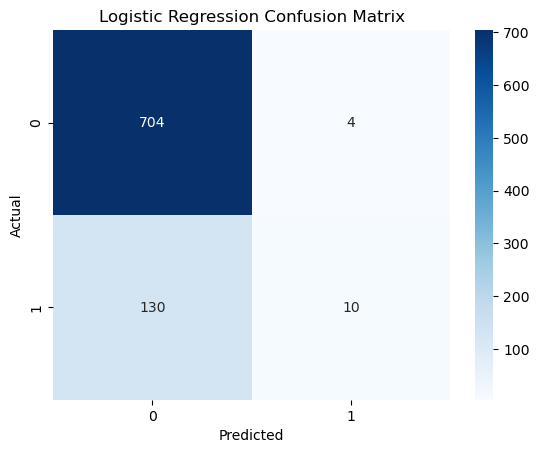

In [69]:
import seaborn as sns
sns.heatmap(LR_cm, annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [70]:
print("\n===== Random Forest =====")
RF_cm = confusion_matrix(y_test, RF_y_pred_test)
RF_cm


===== Random Forest =====


array([[701,   7],
       [133,   7]], dtype=int64)

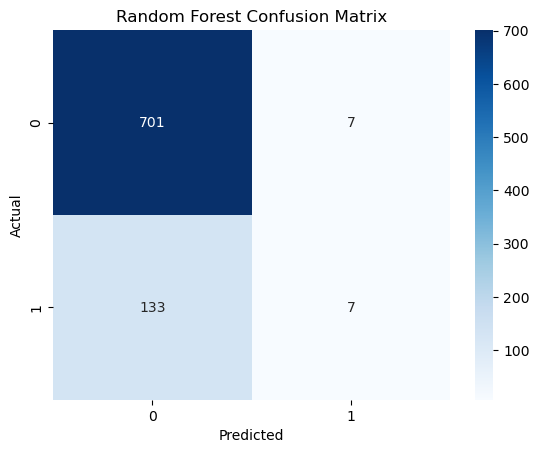

In [71]:
sns.heatmap(RF_cm, annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**ROC Curve**

In [72]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

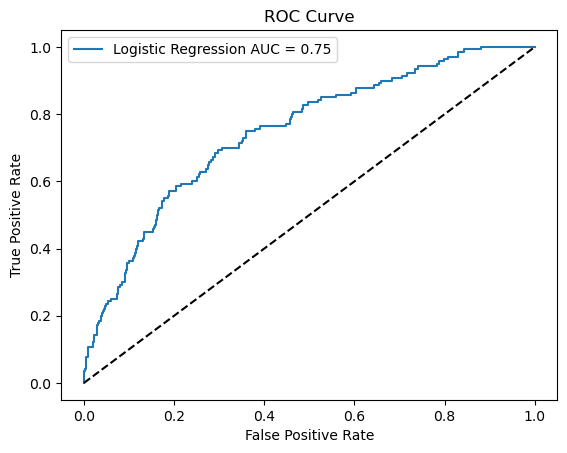

In [73]:
LR_prob = LR_model.predict_proba(x_test)[:,1]
LR_fpr, LR_tpr, _ = roc_curve(y_test, LR_prob)
LR_auc = roc_auc_score(y_test, LR_prob)
plt.figure()
plt.plot(LR_fpr, LR_tpr, label="Logistic Regression AUC = %.2f" % LR_auc)
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

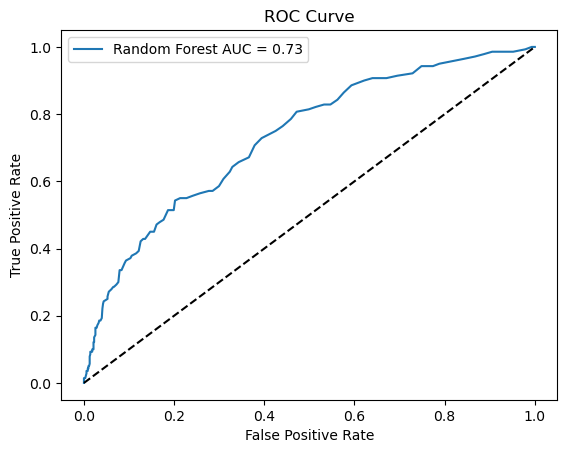

In [74]:
RF_prob = RF_model.predict_proba(x_test)[:,1]
RF_fpr, RF_tpr, _ = roc_curve(y_test, RF_prob)
RF_auc = roc_auc_score(y_test, RF_prob)
plt.figure()
plt.plot(RF_fpr, RF_tpr, label="Random Forest AUC = %.2f" % RF_auc)
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

plt.show()

        2 Models are used for this dataset and to show the results new dataframe is created to compare 2 models

**Model Comparison Table**

In [75]:
results = pd.DataFrame({
    "Model": ["Logistic Regression","Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, LR_y_pred_test),
        accuracy_score(y_test, RF_y_pred_test)
    ],
    "AUC Score": [
        LR_auc,
        RF_auc
    ]
})

print("\n==== Model Comparison ====")
print(results)


==== Model Comparison ====
                 Model  Accuracy  AUC Score
0  Logistic Regression  0.841981   0.747458
1        Random Forest  0.834906   0.731295


c:\Users\mrcoo\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


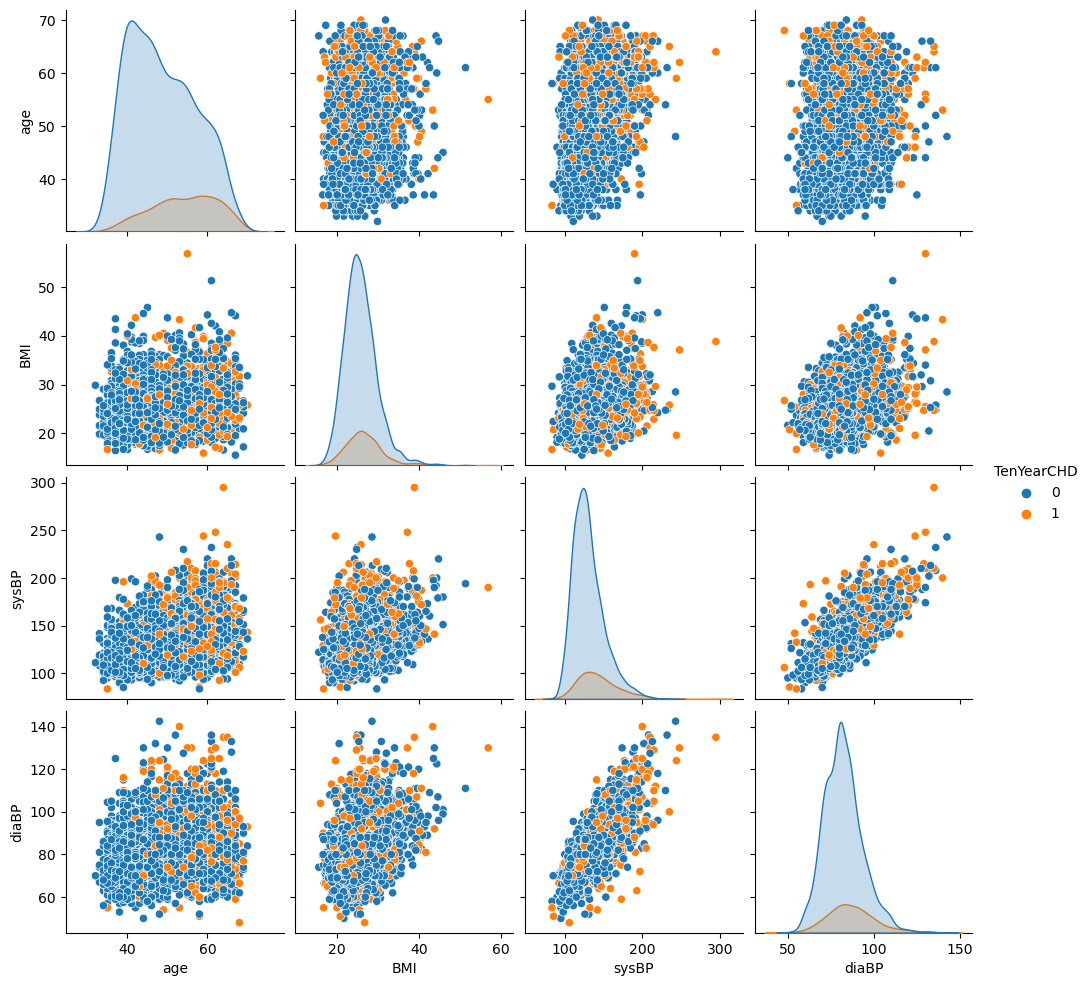

In [76]:
sns.pairplot(df, vars=['age','BMI','sysBP','diaBP'], hue='TenYearCHD')
plt.show()

    Overall, this notebook uses lots of plots using seaborn library. 2 models are used LogisticRegression and RandomForest.
    There is no big difference in the performance of 2 models. LogisticRegression model shows slightly more accuracy score compared to RandomForest.